In [1]:
import math
from math import ceil, sqrt
from typing import List, Optional, Tuple, Dict, Any

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Rectangle, Circle
from hydrax.utils.files import get_data_path
import pandas as pd
import pprint
from hydrax.utils.files import get_data_path
import seaborn as sns

from matplotlib.ticker import FuncFormatter


sns.set_theme(style="whitegrid", rc={"figure.dpi": 300, "font.size": 10, "axes.titlesize": 10, "axes.labelsize": 10, "legend.fontsize": 8})


def extract_single_data(df, df2):
    data = {}
    data["state_cost"] = df["state_cost"].to_numpy()
    data["state_cost_no_cov"] = df2["state_cost"].to_numpy()
    data["success"] = df["success"].to_numpy()
    data["success_no_cov"] = df2["success"].to_numpy()
    data["state_error"] = df["state_error"].to_numpy()
    data["state_error_no_cov"] = df2["state_error"].to_numpy()
    data["T_pos"] = np.array([eval(x) for x in df["qpos"]])[:, :3]
    data["T_pos_no_cov"] = np.array([eval(x) for x in df2["qpos"]])[:, :3]
    # data["ee_pos"] = np.array([eval(x) for x in df["ee_pos"]])
    data["control"] = np.array([eval(x) for x in df["control"]])
    data["control_no_cov"] = np.array([eval(x) for x in df2["control"]])
    return data

def extract_values(path, seeds, controllers):
    data: Dict[int, Dict[str, Dict[str, np.ndarray]]] = {}
    missing: list[str] = []

    for seed in seeds:
        data[seed] = {}
        for controller in controllers:
            file = path / f"{controller}/seed_{seed}_update_cov_True.csv"
            file2 = path / f"{controller}/seed_{seed}_update_cov_False.csv"  
            if not file.exists():
                missing.append(str(file))
                continue
            df = pd.read_csv(file)
            df2 = pd.read_csv(file2)
            data[seed][controller] = extract_single_data(df, df2)

    if missing:
        print("[plot_seeds] Skipped missing files:\n  - " + "\n  - ".join(missing))
    # Safety: filter seeds with at least one controller present
    seeds_present = [s for s in seeds if len(data.get(s, {})) > 0]
    if not seeds_present:
        raise FileNotFoundError("No seed data found. Check paths and filenames.")
    return data



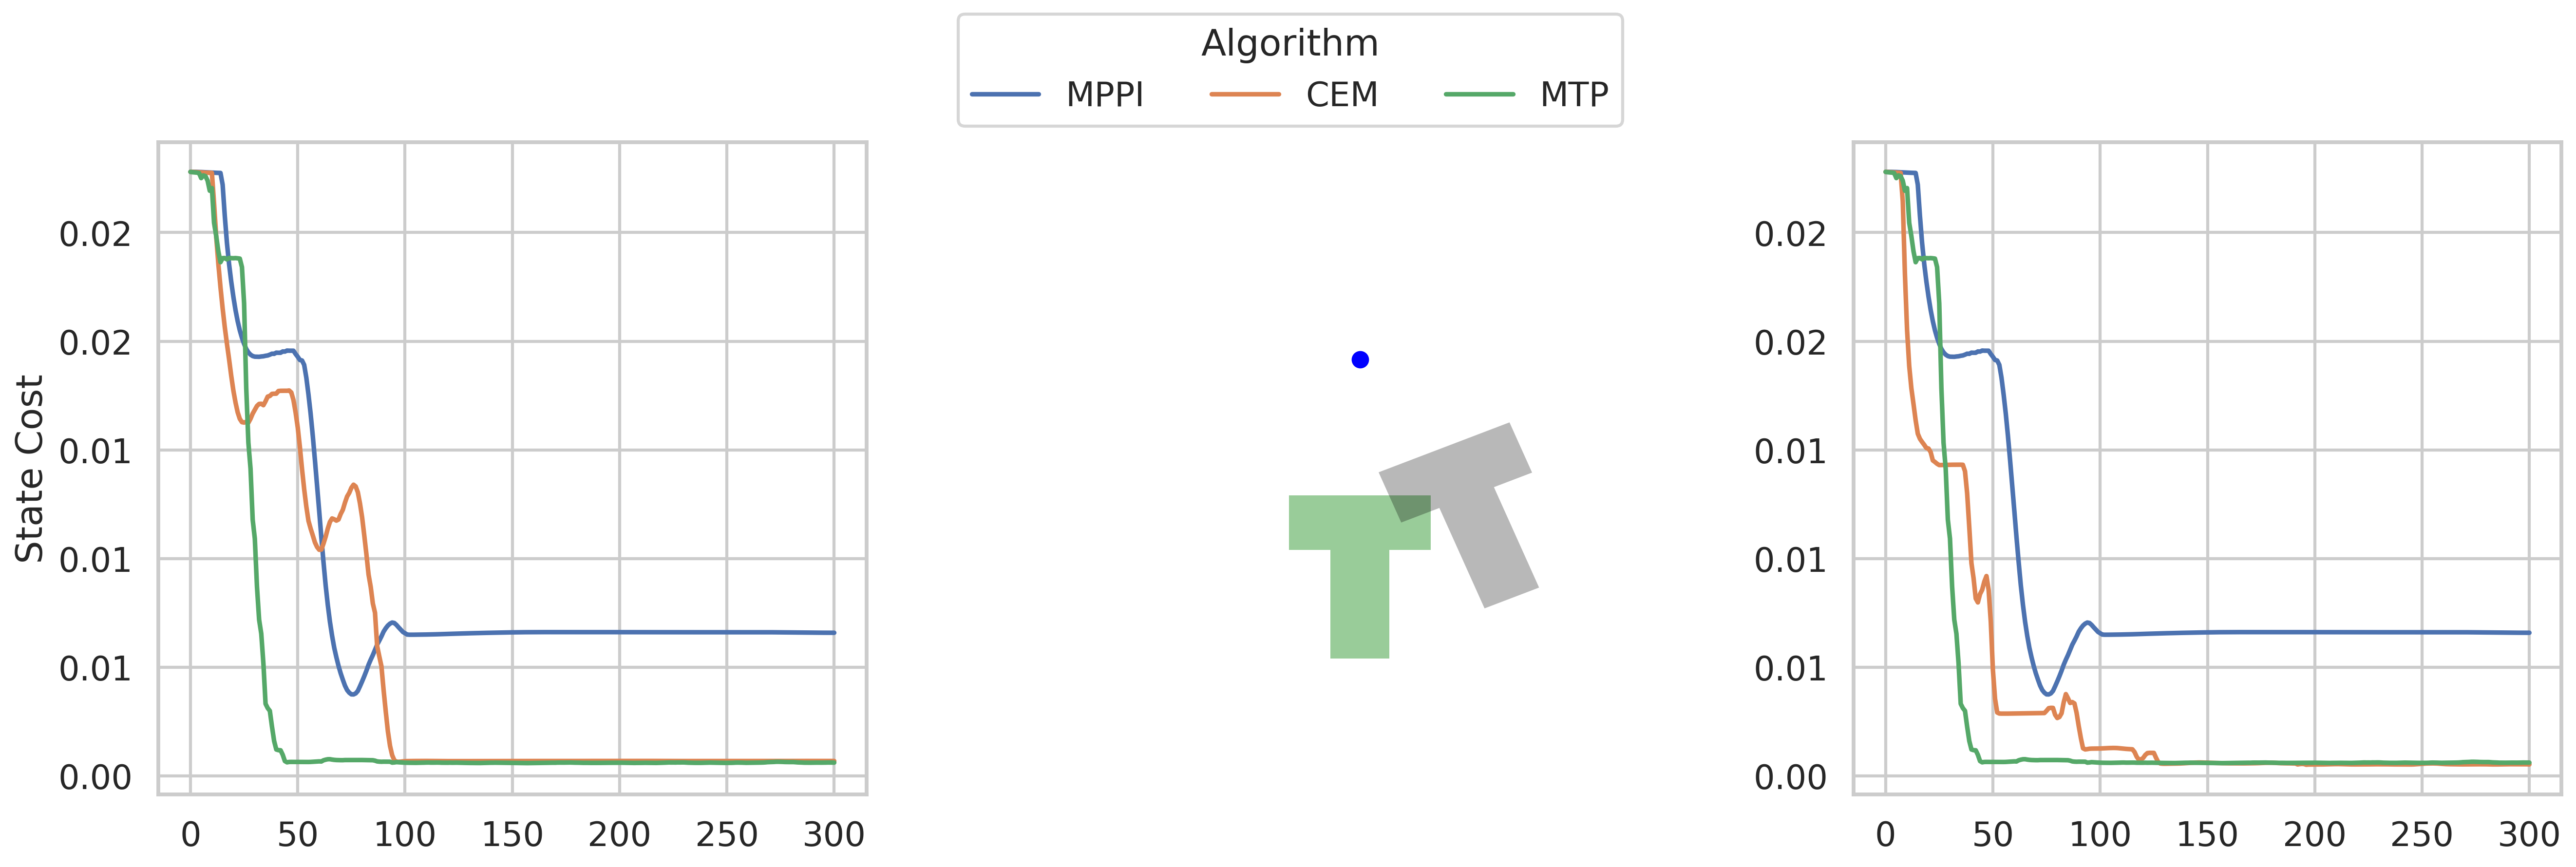

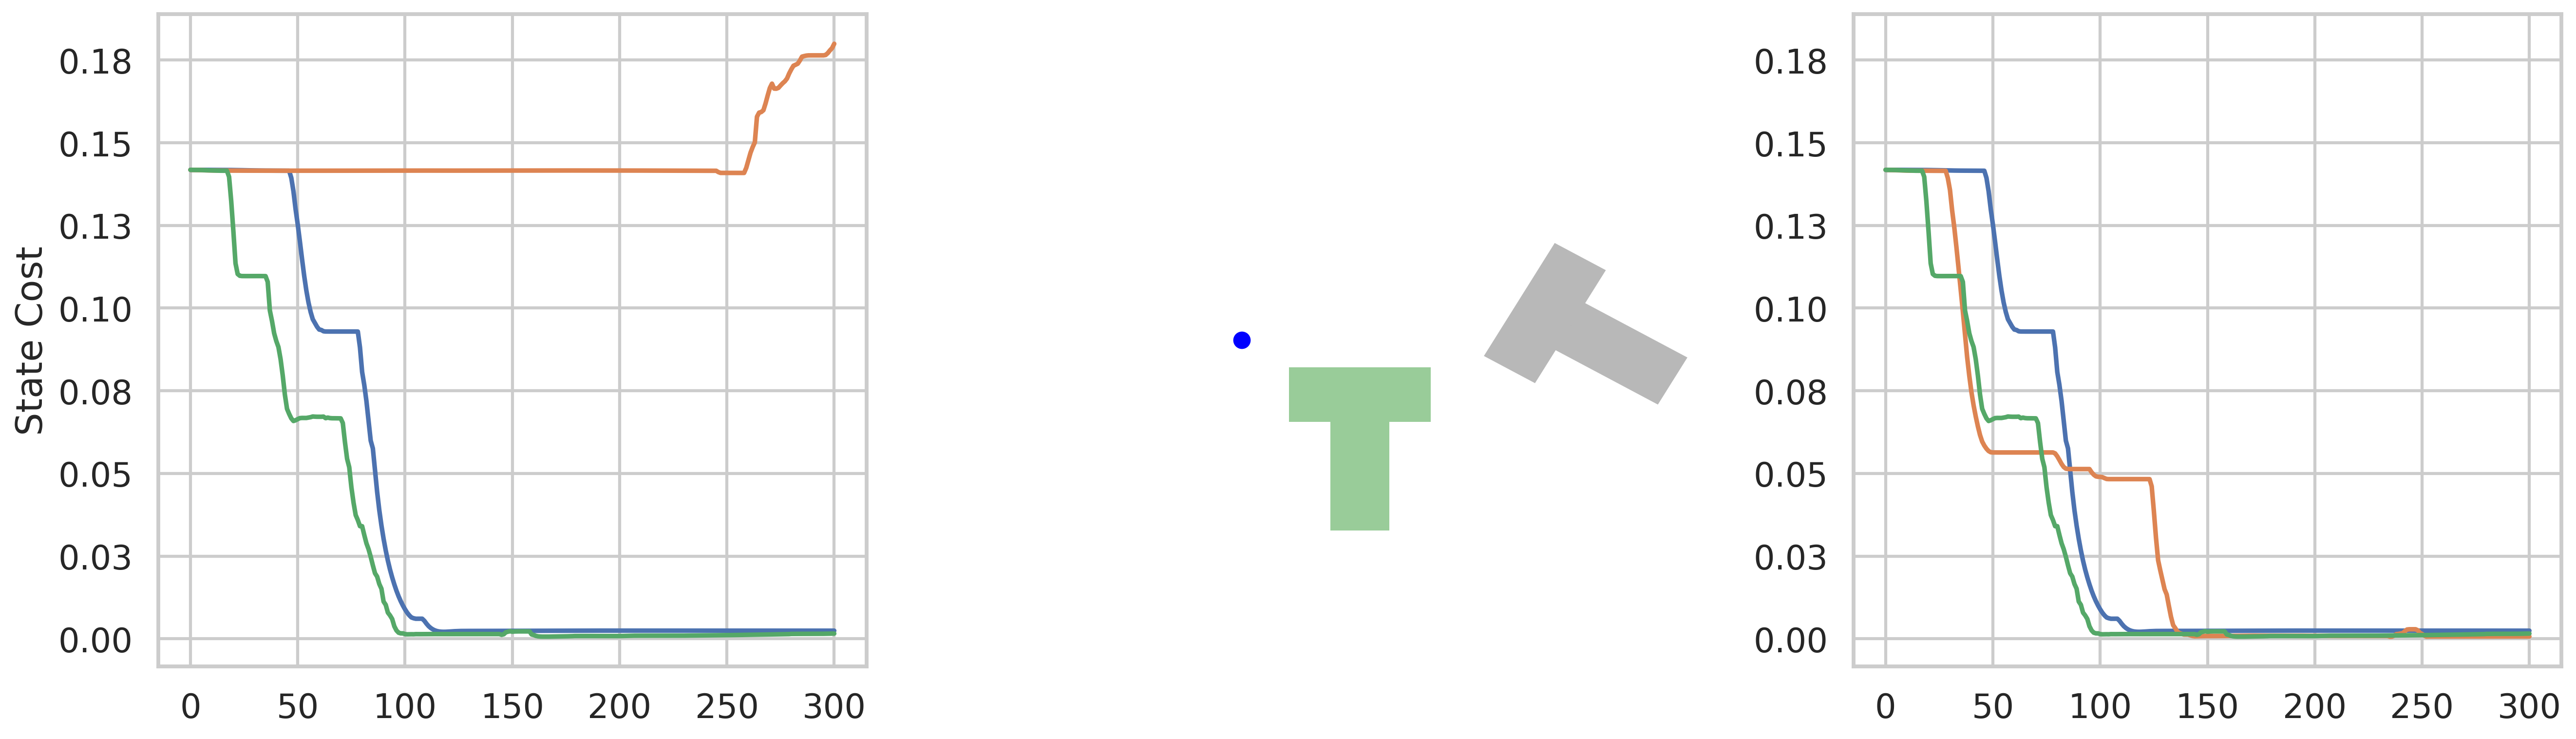

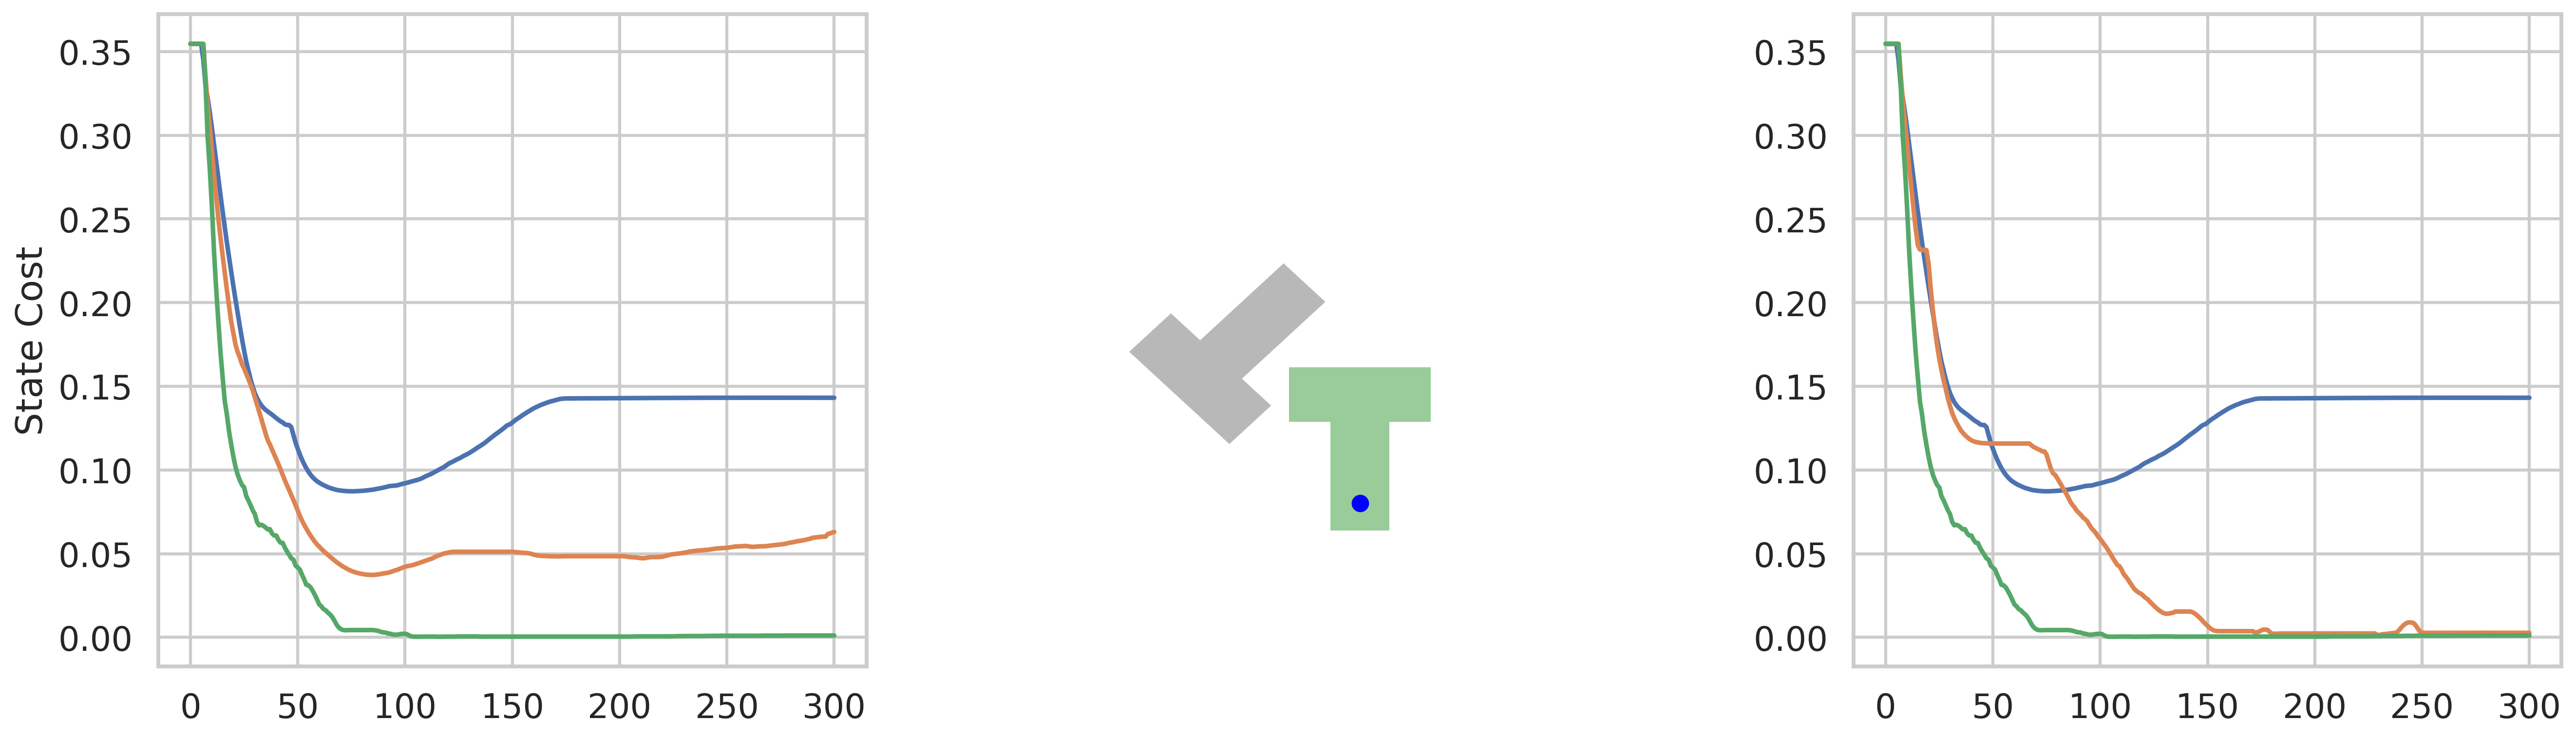

In [42]:


alg_labels = ["MPPI", "CEM", "MTP", "AnMTP"]

# --- Utility functions (your provided versions, with rotmat) ---

def rotmat(yaw: float) -> np.ndarray:
    c, s = math.cos(yaw), math.sin(yaw)
    return np.array([[c, -s],
                     [s,  c]])

def rectangle_corners(center_xy, width, height, yaw):
    cx, cy = center_xy
    R = rotmat(yaw)
    hw, hh = width / 2.0, height / 2.0
    local = np.array([
        [-hw, -hh],
        [ hw, -hh],
        [ hw,  hh],
        [-hw,  hh],
    ])
    world = (local @ R.T) + np.array([cx, cy])
    return world

def t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h):
    stem_center_local = np.array([0.0, -head_h / 2.0])
    head_center_local = np.array([0.0,  stem_h / 2.0])

    stem_center_world = (stem_center_local @ rotmat(yaw).T) + np.array([x, y])
    head_center_world = (head_center_local @ rotmat(yaw).T) + np.array([x, y])

    stem_poly = rectangle_corners(stem_center_world, stem_w, stem_h, yaw)
    head_poly = rectangle_corners(head_center_world, head_w, head_h, yaw)
    return stem_poly, head_poly

def plot_action_space(ax, xmin, xmax, ymin, ymax, show_grid=False, grid_dx=0.25):
    ax.add_patch(Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.5))
    if show_grid and grid_dx > 0:
        xv = np.arange(math.ceil(xmin / grid_dx) * grid_dx, xmax + 1e-9, grid_dx)
        yv = np.arange(math.ceil(ymin / grid_dx) * grid_dx, ymax + 1e-9, grid_dx)
        for xx in xv:
            ax.plot([xx, xx], [ymin, ymax], linewidth=0.4)
        for yy in yv:
            ax.plot([xmin, xmax], [yy, yy], linewidth=0.4)

def draw_t(ax, x, y, yaw_deg, stem_w, stem_h, head_w, head_h,
           face_alpha=0.4, edge_width=0.0, facecolor=None, edgecolor=None, label=None):
    yaw = yaw_deg#math.radians(yaw_deg)
    stem_poly, head_poly = t_shape_polys(x, y, yaw, stem_w, stem_h, head_w, head_h)
    poly_kwargs = dict(closed=True, alpha=face_alpha)
    if facecolor is not None:
        poly_kwargs["facecolor"] = facecolor
    if edgecolor is not None:
        poly_kwargs["edgecolor"] = edgecolor

    stem_patch = Polygon(stem_poly, **poly_kwargs, linewidth=edge_width)
    head_patch = Polygon(head_poly, **poly_kwargs, linewidth=edge_width)
    ax.add_patch(stem_patch)
    ax.add_patch(head_patch)
    if label:
        ax.text(x, y, label, ha="center", va="center", fontsize=10)
    return np.vstack([stem_poly, head_poly])

# --- Main plotting function integrating seaborn and clean T-shapes ---

def plot_seed_data(data: dict, plot_legend: Optional[dict] = None, init_pos: Optional[dict] = None, extension:str= None):
    """
    For each seed, plot:
      1. Error over time (seaborn)
      2. Clean T-shape visualization (goal poses)
      3. Duplicate of error plot
    """
    sns.set(style="whitegrid", context="talk")

    if plot_legend is None:
        plot_legend = {}
        init_pos = {}
        for seed in data.keys():
            plot_legend[seed] = True
            init_pos[seed] = np.array([0.0, -0.05])

    for seed, controllers_data in data.items():
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        ax_error1, ax_Ts, ax_error2 = axes

        # Assign colors
        palette = sns.color_palette("tab10", len(controllers_data))

        # --- (1) & (3): error plots ---
        idx = 0
        for controller, vals in controllers_data.items():
            # err = vals["state_error"]
            err = vals["state_cost"]
            err_no_cov = vals["state_cost_no_cov"]
            df_plot = pd.DataFrame({"time": np.arange(len(err)), "error": err})
            df_plot_no_cov = pd.DataFrame({"time": np.arange(len(err_no_cov)), "error": err_no_cov})
            sns.lineplot(data=df_plot, x="time", y="error", ax=ax_error1,
                         label=alg_labels[idx], legend=False)
            sns.lineplot(data=df_plot_no_cov, x="time", y="error", ax=ax_error2, legend=False)
            # ax_error1.set_yscale("log", base=2)
            # ax_error2.set_yscale("log", base=2)
            idx += 1

        ax_error1.set_xlabel(None); ax_error1.set_ylabel("State Cost")
        ax_error2.set_xlabel(None); ax_error2.set_ylabel(None)
        
        ax_error2.sharey(ax_error1)

        ax_error2.set_yticklabels([])


        ax_error1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))
        ax_error2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.2f}"))
        # --- (2): Clean T-shape plot ---
        ax_Ts.set_facecolor("white")
        
        
        all_points = []

        # Goal
        pts = draw_t(ax_Ts, 0, 0, 0,
                    stem_w=0.05, stem_h=0.1,
                    head_w=0.12, head_h=0.05,
                    facecolor="green",
                    edgecolor=None)
        all_points.append(pts)

        # x and y limits
        #plot ee position as point
        ee_pos = init_pos.get(seed, np.array([0.0, -0.05]))
        ax_Ts.scatter(ee_pos[0], ee_pos[1], s=50, c='blue', zorder=5)
        ax_Ts.set_xlim(-0.3, 0.3)
        ax_Ts.set_ylim(-0.2, 0.4)
        # ax_Ts.axis("equal")
        ax_Ts.axis("off")  # clean background, no ticks or frame
      
        for controller, vals in controllers_data.items():
            T_pos = vals["T_pos"]
            if len(T_pos) == 0:
                continue
            # Initial pose
            init = T_pos[0, :2]
            yaw_deg = T_pos[0, 2]  # placeholder if orientation unknown
            pts = draw_t(ax_Ts, init[0], init[1], yaw_deg,
                         stem_w=0.05, stem_h=0.1,
                         head_w=0.12, head_h=0.05,
                         edgecolor=None, facecolor="black", face_alpha=0.1,)
                        #  label=controller)
            all_points.append(pts)
            # Final pose
            # final = T_pos[-1, :2]
            # yaw_deg = T_pos[-1, 2]  # placeholder if orientation unknown
            # pts = draw_t(ax_Ts, final[0], final[1], yaw_deg,
            #              stem_w=0.05, stem_h=0.1,
            #              head_w=0.12, head_h=0.05,
            #              edgecolor="k", label=controller)
            # all_points.append(pts)

        if all_points:
            all_points = np.vstack(all_points)
            xmin, xmax = np.min(all_points[:, 0]), np.max(all_points[:, 0])
            ymin, ymax = np.min(all_points[:, 1]), np.max(all_points[:, 1])
            margin = 0.1 * max(xmax - xmin, ymax - ymin)
            # ax_Ts.set_xlim(xmin - margin, xmax + margin)
            # ax_Ts.set_ylim(ymin - margin, ymax + margin)
        

        plt.subplots_adjust(top=0.95)

        # ---- Fix the legend duplication ----
        # Get unique handles and labels from one of the subplots
        handles, labels = axes[0].get_legend_handles_labels()
        unique = dict(zip(labels, handles))  # removes duplicates while preserving order
        
        if plot_legend.get(seed, True):
            # Add a single legend for the whole figure
            fig.legend(
                unique.values(),
                unique.keys(),
                title='Algorithm',
                loc='upper center',
                ncol=len(unique),  # one row of legend items
                bbox_to_anchor=(0.5, 1.02)
            )
        plt.tight_layout(rect=[0, 0, 1, 0.9])
        # save as pdf
        if extension:
            plt.savefig(f"seed_{seed}_comparison_{extension}.pdf", bbox_inches='tight', dpi=300)
        else:
            plt.savefig(f"seed_{seed}_comparison.pdf", bbox_inches='tight', dpi=300)
        plt.show()


# alg_labels = ["MPPI", "CEM", "MTP", "AnMTP"]
path = get_data_path() / "pushT_sim"
seeds = [10, 42, 445] 
init_pos = {
    10: np.array([0.0, 0.2]),
    42: np.array([-0.1, 0.1]),
    445: np.array([-0.0, -0.05]),
}
plot_legend = {
    10: True,
    42: False,
    445: False,
}
controllers = ["mppi", "cem", "mtp"]
data = extract_values(path, seeds, controllers)
plot_seed_data(data, plot_legend=plot_legend, init_pos=init_pos)


#! Left is with covariance update, right is without


## Short Horizons

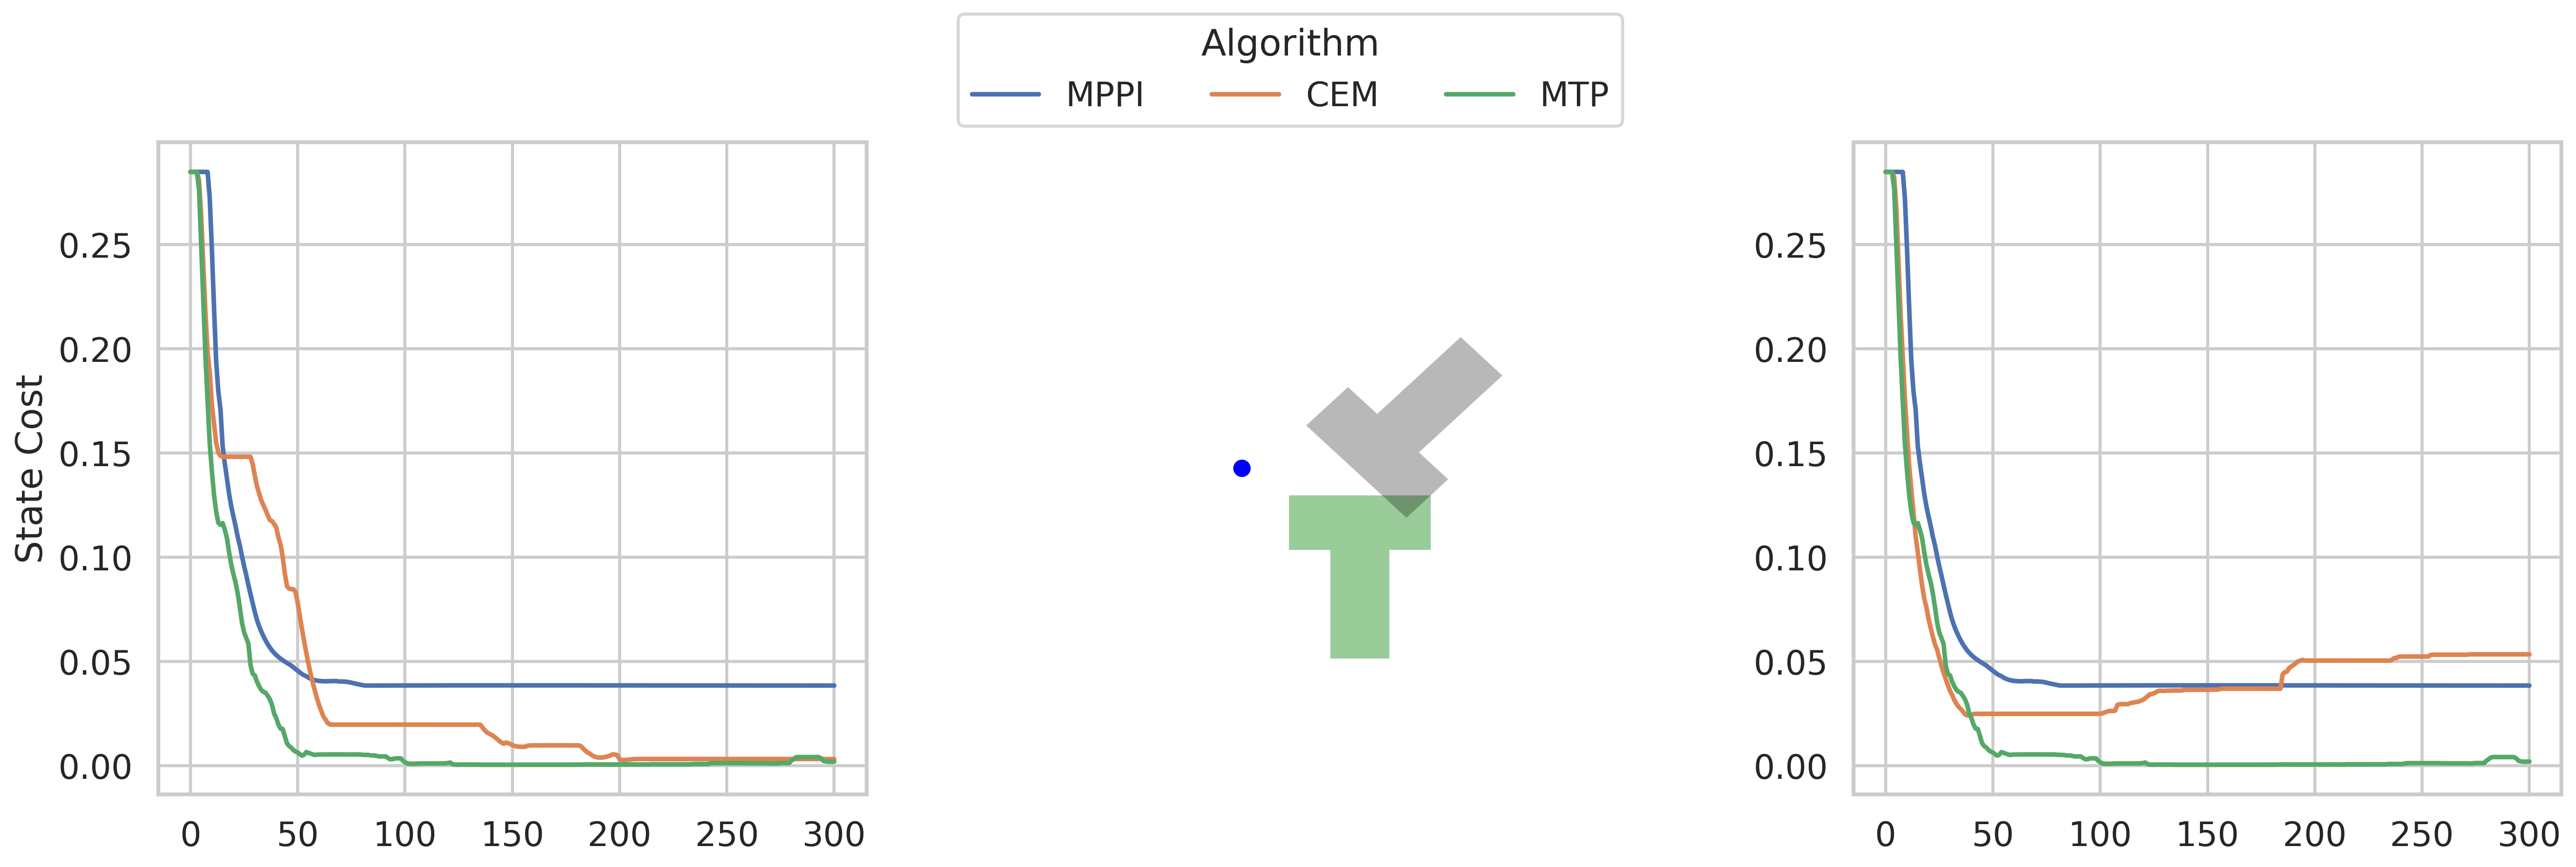

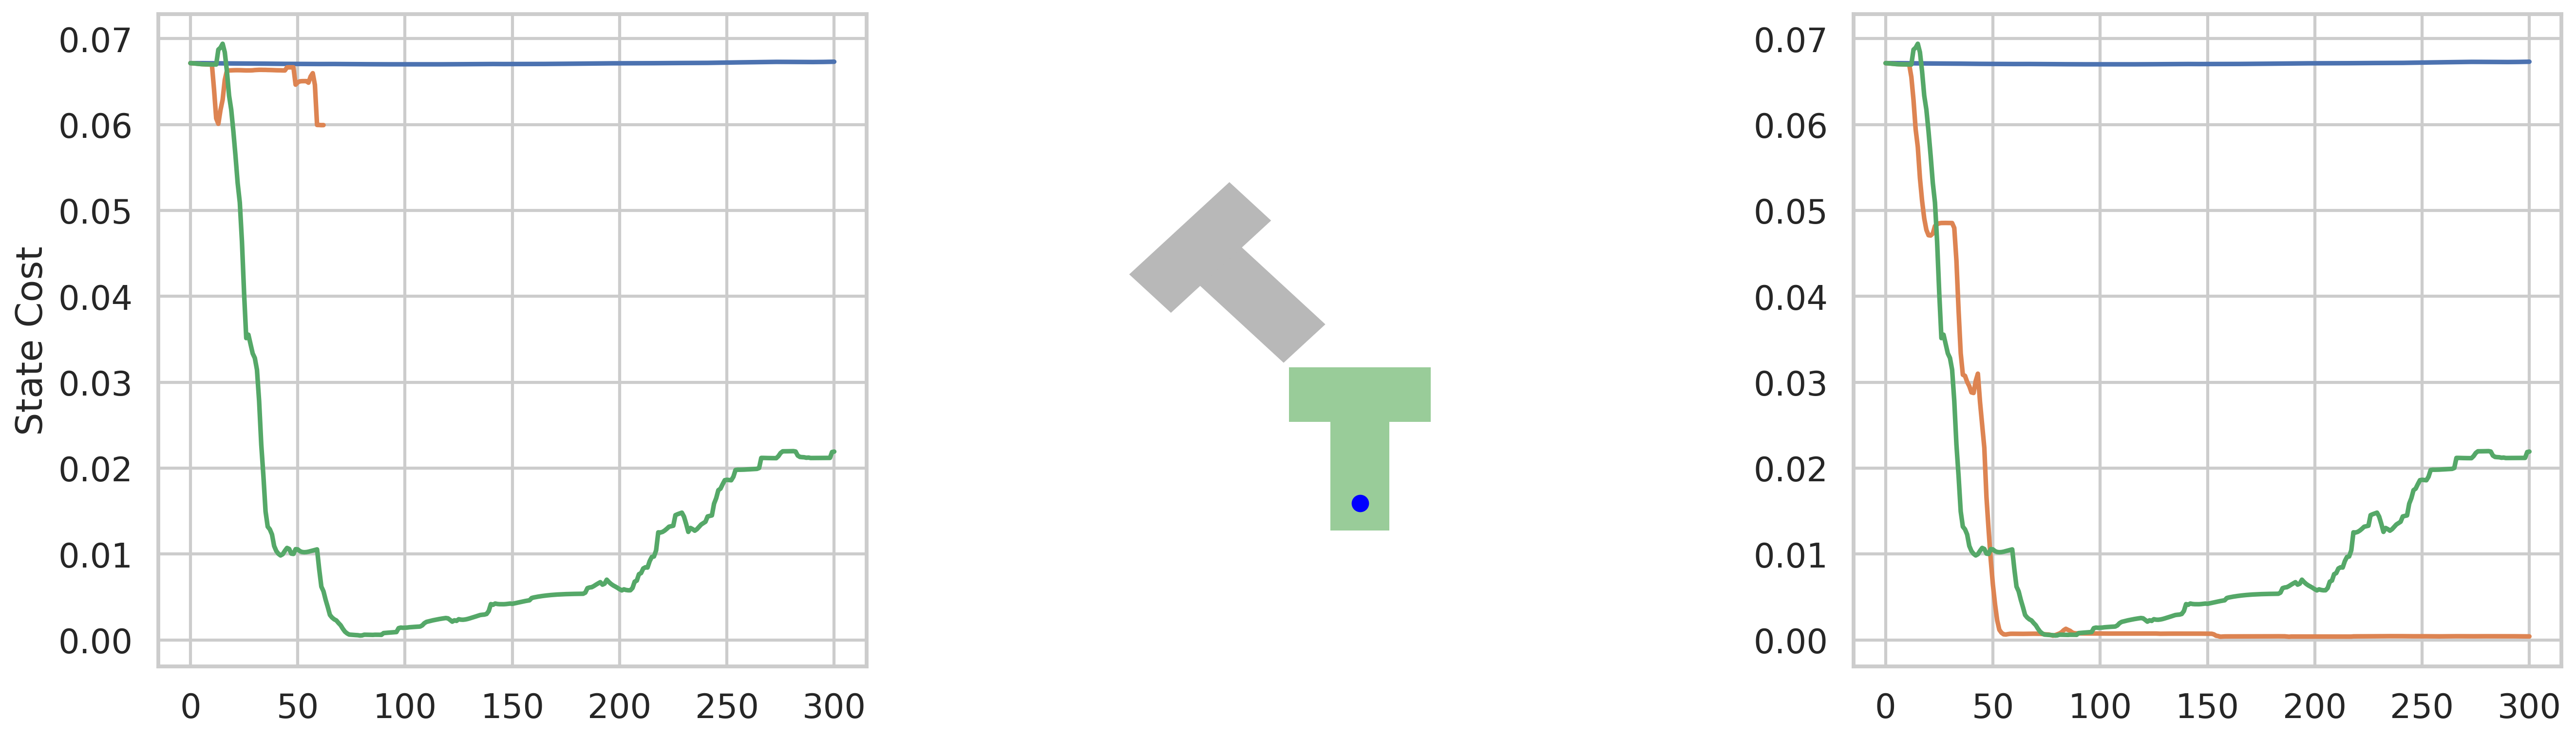

In [45]:
# now for shoret horizon, 256 samples over 10 domains
# alg_labels = ["MPPI", "CEM", "MTP", "AnMTP"]
path = get_data_path() / "pushT_sim"
seeds = [200,100] 
controllers = ["mppi", "cem", "mtp"]

init_pos = {
    100: np.array([0.0, -0.05]),
    200: np.array([-0.1, 0.1]),
}
plot_legend = {
    200: True,
    100: False,
}
data = extract_values(path, seeds, controllers)
plot_seed_data(data, plot_legend=plot_legend, init_pos=init_pos)

## Extensions

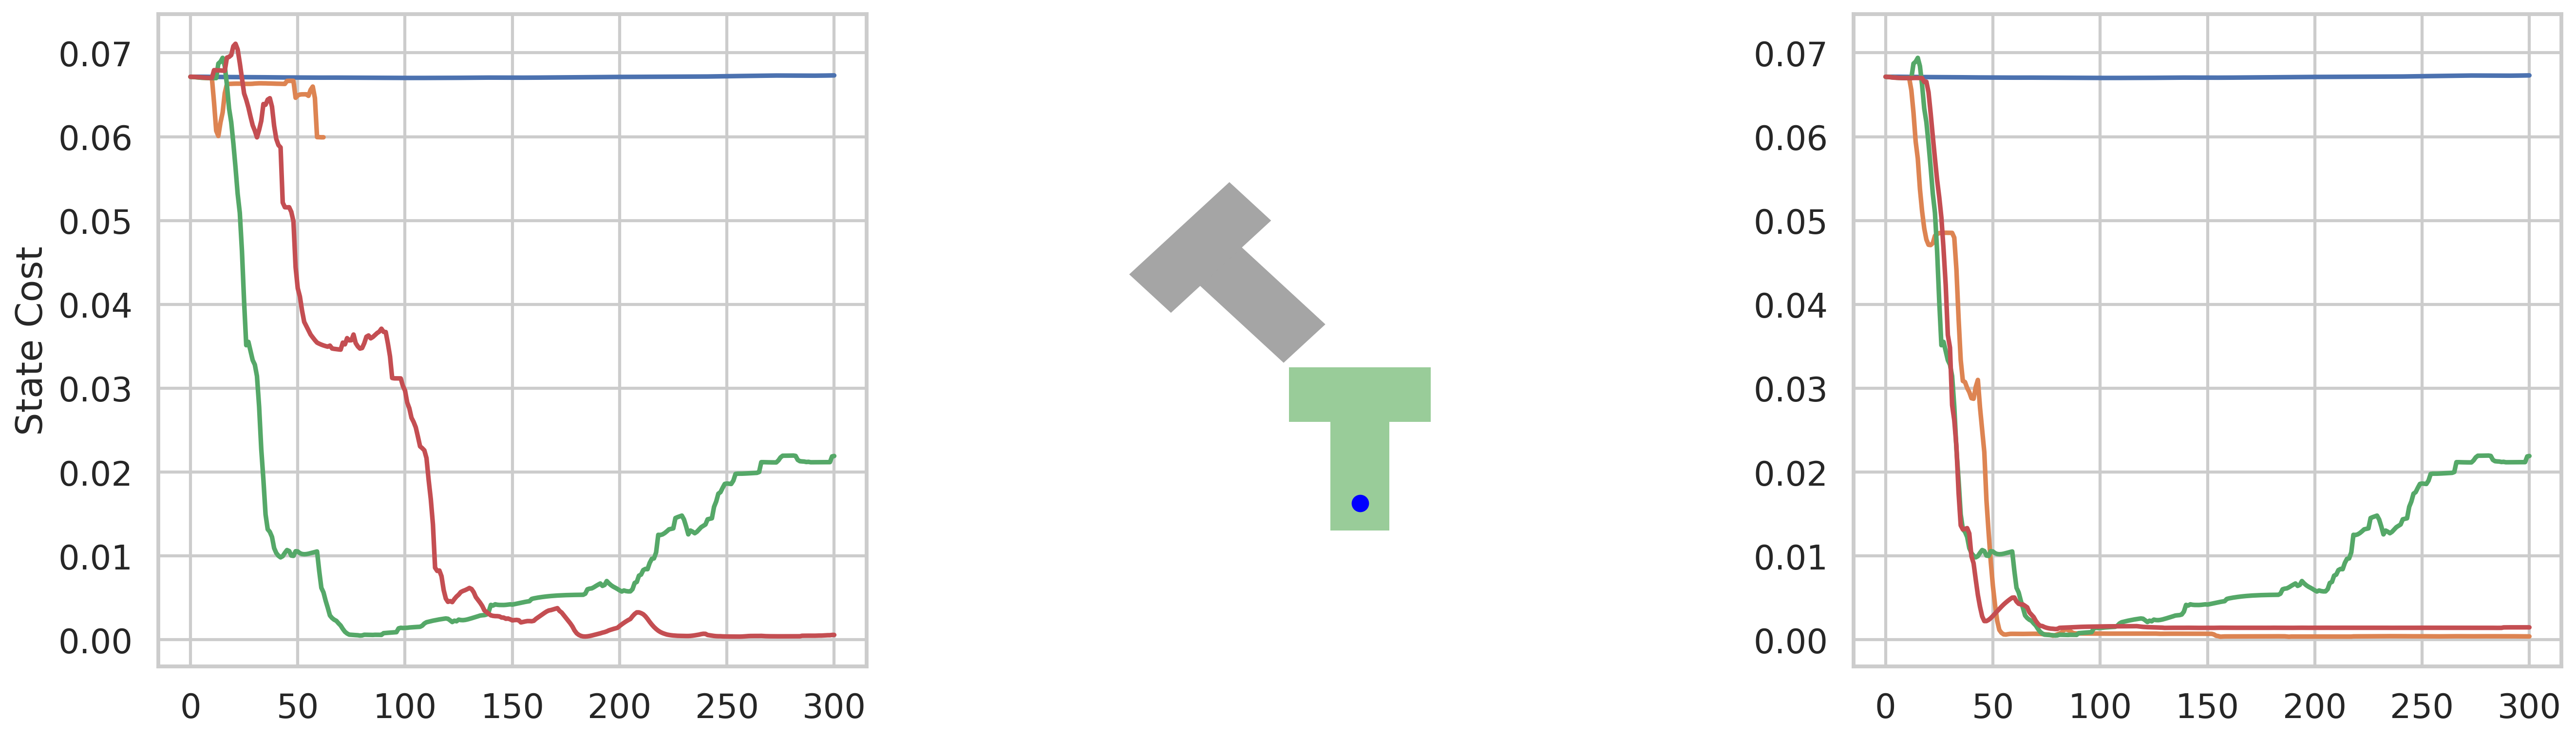

In [46]:
seeds = [100] 
controllers = ["mppi", "cem", "mtp", "anmtp"]
init_pos = {
    100: np.array([0.0, -0.05]),
}
plot_legend = {
    100: False,
}
data = extract_values(path, seeds, controllers)
plot_seed_data(data, plot_legend=plot_legend, init_pos=init_pos)

In [34]:
seeds = [445] 
controllers = ["mppi"]
path = get_data_path() / "pushT_sim" / "colored_noise"
init_pos = {
    100: np.array([0.0, -0.05]),
}
plot_legend = {
    100: False,
}
data = extract_values(path, seeds, controllers)
plot_seed_data(data, plot_legend=plot_legend, init_pos=init_pos, extension="colored_noise")

[plot_seeds] Skipped missing files:
  - /home/mtp/Lab/mtp-thesis/hydrax/../data/pushT_sim/colored_noise/mppi/seed_445_update_cov_True.csv


FileNotFoundError: No seed data found. Check paths and filenames.